# SROIE calibrated risk gate threshold sweep

Purpose: evaluate threshold choices for the calibrated `risk_gate.py` pipeline without changing the script structure.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, brier_score_loss
from sklearn.model_selection import train_test_split

PROJECT_ROOT = Path.cwd().resolve().parent.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_ROOT = PROJECT_ROOT / "Data"
print(PROJECT_ROOT)
print(DATA_ROOT)


/Users/quentin/Documents/Computer/School/CMU/Spring_2026/38616/Gated-Risk-MCP
/Users/quentin/Documents/Computer/School/CMU/Spring_2026/38616/Gated-Risk-MCP/Data


In [2]:
from utils.data_utils import load_sroie_split
from src.sroie.sroie_features import sroie_feature_dataframe, sroie_proxy_label_dataframe, add_derived_features


In [3]:
FEATURE_COLS = [
    "n_tokens",
    "n_boxes",
    "ocr_char_count",
    "ocr_word_count",
    "company_len",
    "date_len",
    "address_len",
    "total_len",
    "n_amount_like_tokens",
    "n_date_like_tokens",
    "token_box_ratio",
    "amount_token_ratio",
    "date_token_ratio",
    "avg_token_len",
    "avg_words_per_token",
    "anchors_present_count",
    "fields_present_count",
    "aspect_ratio",
    "has_total_anchor",
    "has_date_anchor",
    "has_cash_anchor",
]

TARGET_COL = "review_worthy"
RANDOM_STATE = 60
TEST_SIZE = 0.2
N_ESTIMATORS = 100
MAX_DEPTH = 3
LEARNING_RATE = 0.1


In [4]:
records = load_sroie_split("train", data_root=DATA_ROOT)
feature_df = sroie_feature_dataframe(records)
feature_df = add_derived_features(feature_df)
label_df = sroie_proxy_label_dataframe(feature_df)
df = feature_df.merge(label_df, on="doc_id", how="left")

X = df[FEATURE_COLS].values.astype(np.float32)
y = df[TARGET_COL].astype(int).values

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(df.shape)
print(y.mean())
print(y_train.mean(), y_val.mean())


(712, 48)
0.13623595505617977
0.13708260105448156 0.13286713286713286


In [5]:
base_clf = GradientBoostingClassifier(
    n_estimators=N_ESTIMATORS,
    learning_rate=LEARNING_RATE,
    max_depth=MAX_DEPTH,
    random_state=RANDOM_STATE,
)

clf = CalibratedClassifierCV(base_clf, method="isotonic", cv=3)
clf.fit(X_train, y_train)

probs = clf.predict_proba(X_val)[:, 1]

print("auc", roc_auc_score(y_val, probs))
print("brier", brier_score_loss(y_val, probs))
print("min/max prob", probs.min(), probs.max())


auc 0.8081494057724957
brier 0.06391367738271275
min/max prob 0.012820512820512822 1.0


In [6]:
thresholds = np.arange(0.05, 0.95, 0.05)
rows = []

for thr in thresholds:
    pred = (probs >= thr).astype(int)
    rows.append({
        "threshold": thr,
        "accuracy": accuracy_score(y_val, pred),
        "precision": precision_score(y_val, pred, zero_division=0),
        "recall": recall_score(y_val, pred, zero_division=0),
        "f1": f1_score(y_val, pred, zero_division=0),
        "pred_verify_rate": pred.mean(),
        "tp": int(((pred == 1) & (y_val == 1)).sum()),
        "fp": int(((pred == 1) & (y_val == 0)).sum()),
        "fn": int(((pred == 0) & (y_val == 1)).sum()),
        "tn": int(((pred == 0) & (y_val == 0)).sum()),
    })

threshold_df = pd.DataFrame(rows)
display(threshold_df.sort_values(["f1", "recall", "precision"], ascending=False).reset_index(drop=True))


,threshold,accuracy,precision,recall,f1,pred_verify_rate,tp,fp,fn,tn
0,0.30,0.930070,1.000000,0.473684,0.642857,0.062937,9,0,10,124
1,0.35,0.930070,1.000000,0.473684,0.642857,0.062937,9,0,10,124
2,0.40,0.930070,1.000000,0.473684,0.642857,0.062937,9,0,10,124
3,0.45,0.930070,1.000000,0.473684,0.642857,0.062937,9,0,10,124
4,0.50,0.930070,1.000000,0.473684,0.642857,0.062937,9,0,10,124
5,0.55,0.930070,1.000000,0.473684,0.642857,0.062937,9,0,10,124
6,0.60,0.930070,1.000000,0.473684,0.642857,0.062937,9,0,10,124
7,0.65,0.930070,1.000000,0.473684,0.642857,0.062937,9,0,10,124
8,0.70,0.930070,1.000000,0.473684,0.642857,0.062937,9,0,10,124
9,0.75,0.930070,1.000000,0.473684,0.642857,0.062937,9,0,10,124


In [7]:
best_f1 = threshold_df.sort_values(["f1", "recall", "precision"], ascending=False).iloc[0]
best_recall_at_precision_1 = threshold_df.loc[threshold_df["precision"] == 1.0].sort_values(["recall", "f1"], ascending=False).head(10)
closest_to_target_rate = threshold_df.assign(rate_gap=(threshold_df["pred_verify_rate"] - y_val.mean()).abs()).sort_values(["rate_gap", "f1"]).head(10)

print("best F1 row")
display(best_f1.to_frame().T)

print("best rows with precision = 1.0")
display(best_recall_at_precision_1)

print("rows closest to validation positive rate")
display(closest_to_target_rate)


best F1 row


,threshold,accuracy,precision,recall,f1,pred_verify_rate,tp,fp,fn,tn
5,0.3,0.93007,1.0,0.473684,0.642857,0.062937,9.0,0.0,10.0,124.0


best rows with precision = 1.0


,threshold,accuracy,precision,recall,f1,pred_verify_rate,tp,fp,fn,tn
5,0.30,0.93007,1.0,0.473684,0.642857,0.062937,9,0,10,124
6,0.35,0.93007,1.0,0.473684,0.642857,0.062937,9,0,10,124
7,0.40,0.93007,1.0,0.473684,0.642857,0.062937,9,0,10,124
8,0.45,0.93007,1.0,0.473684,0.642857,0.062937,9,0,10,124
9,0.50,0.93007,1.0,0.473684,0.642857,0.062937,9,0,10,124
10,0.55,0.93007,1.0,0.473684,0.642857,0.062937,9,0,10,124
11,0.60,0.93007,1.0,0.473684,0.642857,0.062937,9,0,10,124
12,0.65,0.93007,1.0,0.473684,0.642857,0.062937,9,0,10,124
13,0.70,0.93007,1.0,0.473684,0.642857,0.062937,9,0,10,124
14,0.75,0.93007,1.0,0.473684,0.642857,0.062937,9,0,10,124


rows closest to validation positive rate


,threshold,accuracy,precision,recall,f1,pred_verify_rate,tp,fp,fn,tn,rate_gap
2,0.15,0.916084,0.818182,0.473684,0.600000,0.076923,9,2,10,122,0.055944
3,0.20,0.916084,0.818182,0.473684,0.600000,0.076923,9,2,10,122,0.055944
4,0.25,0.923077,0.900000,0.473684,0.620690,0.069930,9,1,10,123,0.062937
5,0.30,0.930070,1.000000,0.473684,0.642857,0.062937,9,0,10,124,0.069930
6,0.35,0.930070,1.000000,0.473684,0.642857,0.062937,9,0,10,124,0.069930
7,0.40,0.930070,1.000000,0.473684,0.642857,0.062937,9,0,10,124,0.069930
8,0.45,0.930070,1.000000,0.473684,0.642857,0.062937,9,0,10,124,0.069930
9,0.50,0.930070,1.000000,0.473684,0.642857,0.062937,9,0,10,124,0.069930
10,0.55,0.930070,1.000000,0.473684,0.642857,0.062937,9,0,10,124,0.069930
11,0.60,0.930070,1.000000,0.473684,0.642857,0.062937,9,0,10,124,0.069930


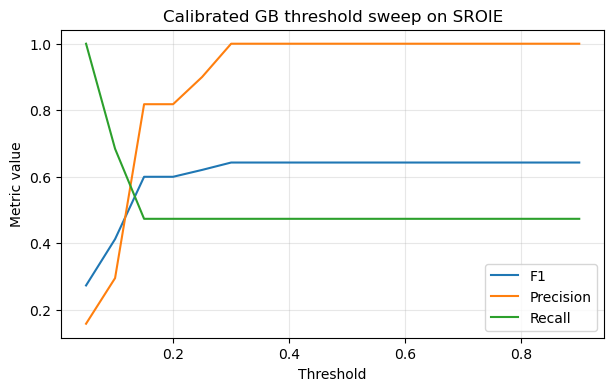

In [8]:
plt.figure(figsize=(7, 4))
plt.plot(threshold_df["threshold"], threshold_df["f1"], label="F1")
plt.plot(threshold_df["threshold"], threshold_df["precision"], label="Precision")
plt.plot(threshold_df["threshold"], threshold_df["recall"], label="Recall")
plt.xlabel("Threshold")
plt.ylabel("Metric value")
plt.title("Calibrated GB threshold sweep on SROIE")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


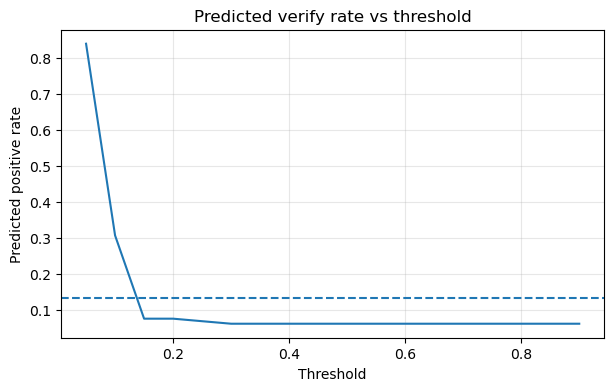

In [9]:
plt.figure(figsize=(7, 4))
plt.plot(threshold_df["threshold"], threshold_df["pred_verify_rate"])
plt.axhline(y=y_val.mean(), linestyle="--")
plt.xlabel("Threshold")
plt.ylabel("Predicted positive rate")
plt.title("Predicted verify rate vs threshold")
plt.grid(True, alpha=0.3)
plt.show()
